## Personal Fitness Tracker Dashboard

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [ ]:
DATA_FILE = "fitness_activities.csv"

REQUIRED_COLUMNS = [
    "Date",
    "Activity Type",
    "Duration",
    "Calories Burned"
]

VALID_ACTIVITIES = [
    "Running",
    "Walking",
    "Cycling",
    "Yoga",
    "Strength Training"
]

print("Dataset:", DATA_FILE)
print("Supported activities:", ", ".join(VALID_ACTIVITIES))

Dataset: fitness_activities.csv
Supported activities: Running, Walking, Cycling, Yoga, Strength Training


In [20]:
class FitnessTracker:
    def __init__(self, data_file=DATA_FILE):
        self.data_file = data_file
        self.data = pd.DataFrame(columns=REQUIRED_COLUMNS)
        self.load_data()

    def load_data(self):
        if os.path.exists(self.data_file):
            try:
                self.data = pd.read_csv(self.data_file)
            except Exception as error:
                print("Could not read dataset:", error)
                self.data = pd.DataFrame(columns=REQUIRED_COLUMNS)

        
        for column in REQUIRED_COLUMNS:
            if column not in self.data.columns:
                self.data[column] = np.nan

        self.data = self.data[REQUIRED_COLUMNS]
        self.clean_data()

    def clean_data(self):
        
        self.data["Date"] = pd.to_datetime(self.data["Date"], errors="coerce")
        self.data["Duration"] = pd.to_numeric(self.data["Duration"], errors="coerce")
        self.data["Calories Burned"] = pd.to_numeric(
            self.data["Calories Burned"], errors="coerce"
        )

        self.data["Activity Type"] = (
            self.data["Activity Type"].astype("string").str.strip()
        )

        
        self.data.dropna(subset=REQUIRED_COLUMNS, inplace=True)
        self.data = self.data[
            (self.data["Duration"] > 0) &
            (self.data["Calories Burned"] > 0)
        ].copy()

        self.data.sort_values("Date", inplace=True)
        self.data.reset_index(drop=True, inplace=True)

    def log_activity(self, activity_type, duration, calories, date=None):
        
        if not isinstance(activity_type, str) or not activity_type.strip():
            raise ValueError("Activity type cannot be empty.")

        activity_type = activity_type.strip()

        if activity_type not in VALID_ACTIVITIES:
            raise ValueError(
                f"Invalid activity. Choose from: {', '.join(VALID_ACTIVITIES)}"
            )

        if duration <= 0:
            raise ValueError("Duration must be greater than 0.")

        if calories <= 0:
            raise ValueError("Calories burned must be greater than 0.")

        if date is None:
            date = pd.Timestamp.today().normalize()
        else:
            date = pd.to_datetime(date, errors="coerce")
            if pd.isna(date):
                raise ValueError("Invalid date. Use YYYY-MM-DD.")

        new_row = pd.DataFrame([{
            "Date": date,
            "Activity Type": activity_type,
            "Duration": float(duration),
            "Calories Burned": float(calories)
        }])

        self.data = pd.concat([self.data, new_row], ignore_index=True)
        self.data.sort_values("Date", inplace=True)
        self.data.reset_index(drop=True, inplace=True)

        
        self.save_data()

        return "Activity logged successfully."

    def save_data(self):
        export_data = self.data.copy()
        export_data["Date"] = export_data["Date"].dt.strftime("%Y-%m-%d")
        export_data.to_csv(self.data_file, index=False)

    def calculate_metrics(self):
        if self.data.empty:
            return {
                "total_calories": 0,
                "average_duration": 0,
                "activity_frequency": 0,
                "total_duration": 0,
                "calories_per_minute": 0
            }

        durations = self.data["Duration"].to_numpy(dtype=float)
        calories = self.data["Calories Burned"].to_numpy(dtype=float)

        
        total_calories = np.sum(calories)
        average_duration = np.mean(durations)
        total_duration = np.sum(durations)

        activity_frequency = self.data["Activity Type"].value_counts().to_dict()

        calories_per_minute = (
            total_calories / total_duration if total_duration > 0 else 0
        )

        return {
            "total_calories": total_calories,
            "average_duration": average_duration,
            "activity_frequency": activity_frequency,
            "total_duration": total_duration,
            "calories_per_minute": calories_per_minute
        }

    def filter_activities(self, condition=None, activity_type=None,
                          start_date=None, end_date=None):
        result = self.data.copy()

        if activity_type:
            result = result[
                result["Activity Type"].str.lower() == activity_type.strip().lower()
            ]

        if start_date:
            start_date = pd.to_datetime(start_date, errors="coerce")
            if pd.isna(start_date):
                raise ValueError("Invalid start date.")
            result = result[result["Date"] >= start_date]

        if end_date:
            end_date = pd.to_datetime(end_date, errors="coerce")
            if pd.isna(end_date):
                raise ValueError("Invalid end date.")
            result = result[result["Date"] <= end_date]

        if condition is not None:
            result = result[condition(result)]

        return result.reset_index(drop=True)

    def generate_report(self):
        metrics = self.calculate_metrics()

        print("\n" + "=" * 55)
        print("           PERSONAL FITNESS REPORT")
        print("=" * 55)
        print(f"Total activities       : {len(self.data)}")
        print(f"Total duration (mins)  : {metrics['total_duration']:.1f}")
        print(f"Total calories burned  : {metrics['total_calories']:.1f}")
        print(f"Average duration       : {metrics['average_duration']:.1f} mins")
        print(f"Calories per minute    : {metrics['calories_per_minute']:.2f}")
        print("\nActivity frequency:")
        for activity, count in metrics["activity_frequency"].items():
            print(f"  - {activity}: {count}")
        print("=" * 55)

        return metrics


tracker = FitnessTracker()
print(f"Dataset loaded: {len(tracker.data)} records")
tracker.data.head()

Dataset loaded: 15 records


,Date,Activity Type,Duration,Calories Burned
0,2026-09-01,Running,30,320
1,2026-09-02,Yoga,45,180
2,2026-09-03,Cycling,50,420
3,2026-09-04,Walking,40,190
4,2026-09-05,Running,35,360


## 4. Data Loading and Analysis — Pandas + NumPy

In [ ]:
print("Dataset shape:", tracker.data.shape)
display(tracker.data)

print("\nData types:")
display(tracker.data.dtypes)

Dataset shape: (15, 4)


,Date,Activity Type,Duration,Calories Burned
0,2026-09-01,Running,30,320
1,2026-09-02,Yoga,45,180
2,2026-09-03,Cycling,50,420
3,2026-09-04,Walking,40,190
4,2026-09-05,Running,35,360
5,2026-09-06,Strength Training,55,410
6,2026-09-07,Yoga,30,130
7,2026-09-08,Cycling,60,500
8,2026-09-09,Walking,45,215
9,2026-09-10,Running,40,410



Data types:


Date               datetime64[us]
Activity Type              string
Duration                    int64
Calories Burned             int64
dtype: object

In [ ]:
metrics = tracker.calculate_metrics()

print(f"Total Calories Burned : {metrics['total_calories']:.1f}")
print(f"Average Duration      : {metrics['average_duration']:.1f} minutes")
print(f"Total Duration        : {metrics['total_duration']:.1f} minutes")
print(f"Calories per Minute   : {metrics['calories_per_minute']:.2f}")

print("\nActivity Frequency:")
display(pd.Series(metrics["activity_frequency"], name="Count").to_frame())

Total Calories Burned : 4855.0
Average Duration      : 45.3 minutes
Total Duration        : 680.0 minutes
Calories per Minute   : 7.14

Activity Frequency:


,Count
Running,4
Yoga,3
Cycling,3
Walking,3
Strength Training,2


In [ ]:
analysis_df = tracker.data.copy()
analysis_df["Calories per Minute"] = (
    analysis_df["Calories Burned"] / analysis_df["Duration"]
)

activity_summary = (
    analysis_df
    .groupby("Activity Type")
    .agg(
        Sessions=("Activity Type", "count"),
        Total_Duration=("Duration", "sum"),
        Total_Calories=("Calories Burned", "sum"),
        Average_Duration=("Duration", "mean"),
        Average_Calories=("Calories Burned", "mean"),
        Average_Calories_Per_Minute=("Calories per Minute", "mean")
    )
    .sort_values("Total_Calories", ascending=False)
)

display(activity_summary.round(2))

,Sessions,Total_Duration,Total_Calories,Average_Duration,Average_Calories,Average_Calories_Per_Minute
Activity Type,,,,,,
Running,4,150,1540,37.50,385.00,10.30
Cycling,3,155,1310,51.67,436.67,8.47
Strength Training,2,105,790,52.50,395.00,7.53
Walking,3,145,695,48.33,231.67,4.79
Yoga,3,125,520,41.67,173.33,4.18


In [ ]:
weekly_trend = (
    analysis_df.set_index("Date")
    .resample("W")
    .agg(
        Total_Duration=("Duration", "sum"),
        Total_Calories=("Calories Burned", "sum"),
        Sessions=("Activity Type", "count")
    )
)

display(weekly_trend)

,Total_Duration,Total_Calories,Sessions
Date,,,
2026-09-06,255,1880,6
2026-09-13,320,2235,7
2026-09-20,105,740,2


##  5. User Input and Data Validation

In [8]:
def get_positive_number(prompt, number_type=float):
    while True:
        try:
            value = number_type(input(prompt))
            if value <= 0:
                print("Please enter a value greater than 0.")
                continue
            return value
        except ValueError:
            print("Invalid input. Please enter a valid number.")


def add_activity_interactively(tracker):
    print("\n--- Add New Fitness Activity ---")

    while True:
        activity = input(
            f"Activity ({'/'.join(VALID_ACTIVITIES)}): "
        ).strip()

        if activity in VALID_ACTIVITIES:
            break

        print("Invalid activity. Please choose one from the list.")

    duration = get_positive_number("Duration in minutes: ", float)
    calories = get_positive_number("Calories burned: ", float)

    while True:
        date_text = input(
            "Date (YYYY-MM-DD) [press Enter for today]: "
        ).strip()

        if date_text == "":
            date_text = None
            break

        try:
            parsed_date = pd.to_datetime(date_text, errors="raise")
            date_text = parsed_date.strftime("%Y-%m-%d")
            break
        except Exception:
            print("Invalid date. Please use YYYY-MM-DD.")

    try:
        message = tracker.log_activity(
            activity_type=activity,
            duration=duration,
            calories=calories,
            date=date_text
        )
        print(message)
    except ValueError as error:
        print("Error:", error)

## 6. Data Visualization

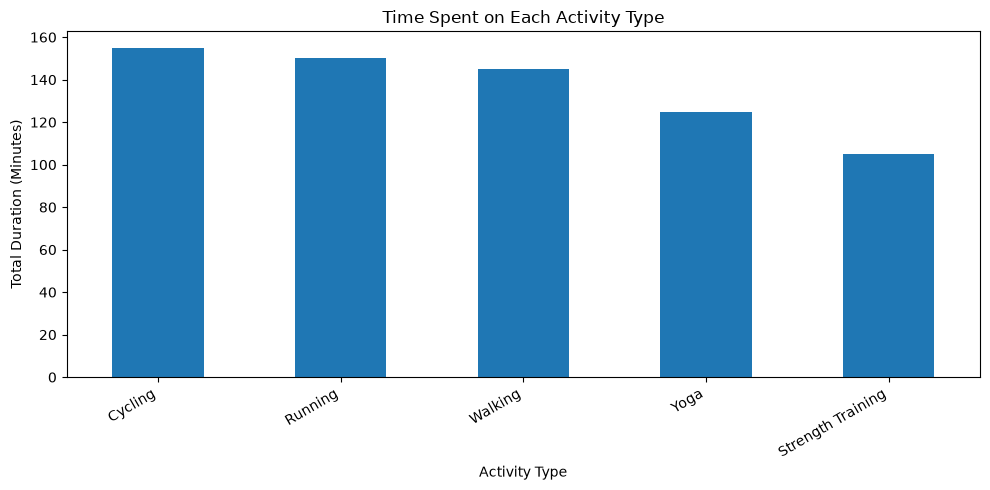

In [ ]:
time_by_activity = (
    tracker.data.groupby("Activity Type")["Duration"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
time_by_activity.plot(kind="bar")
plt.title("Time Spent on Each Activity Type")
plt.xlabel("Activity Type")
plt.ylabel("Total Duration (Minutes)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

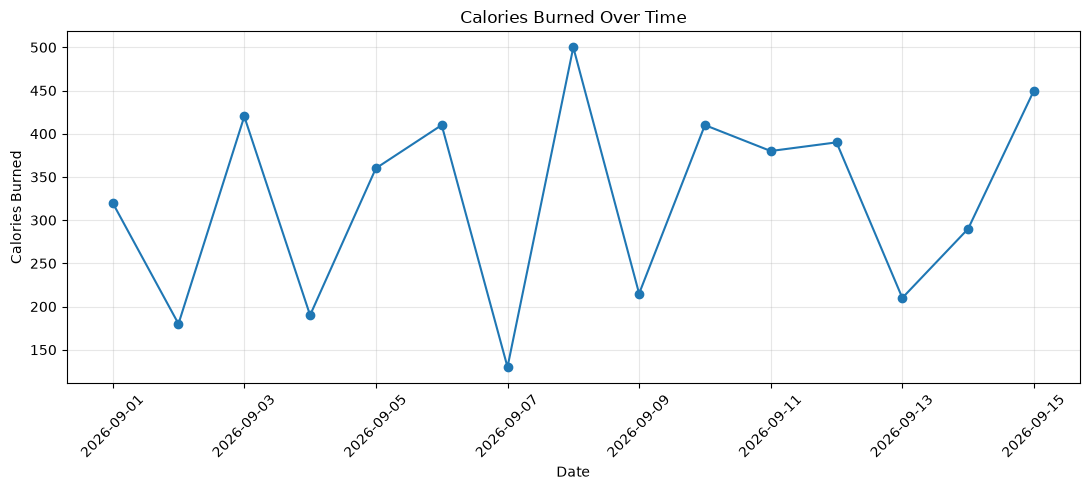

In [ ]:
daily_calories = (
    tracker.data.groupby("Date")["Calories Burned"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(11, 5))
plt.plot(daily_calories.index, daily_calories.values, marker="o")
plt.title("Calories Burned Over Time")
plt.xlabel("Date")
plt.ylabel("Calories Burned")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

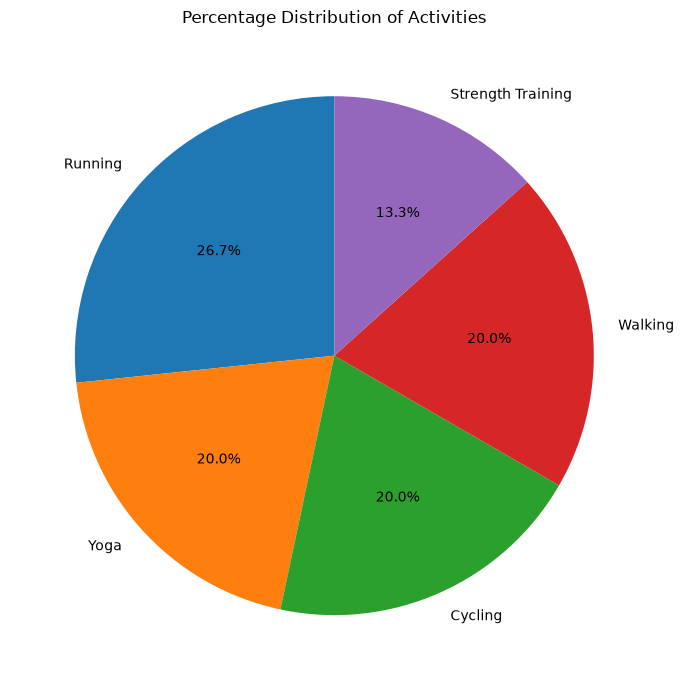

In [ ]:
activity_counts = tracker.data["Activity Type"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    activity_counts.values,
    labels=activity_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Percentage Distribution of Activities")
plt.tight_layout()
plt.show()

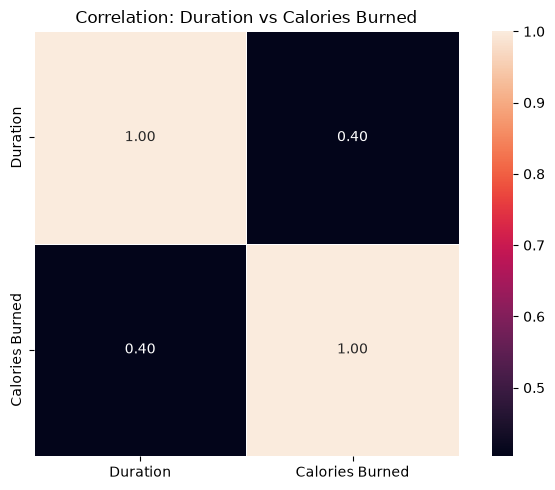

In [ ]:
correlation_data = tracker.data[["Duration", "Calories Burned"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    correlation_data,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True
)
plt.title("Correlation: Duration vs Calories Burned")
plt.tight_layout()
plt.show()

## 7. Filtering Examples

In [21]:
running_data = tracker.filter_activities(activity_type="Running")
print("Running Activities:")
display(running_data)

Running Activities:


,Date,Activity Type,Duration,Calories Burned
0,2026-09-01,Running,30,320
1,2026-09-05,Running,35,360
2,2026-09-10,Running,40,410
3,2026-09-15,Running,45,450


In [ ]:
date_filtered = tracker.filter_activities(
    start_date="2026-09-01",
    end_date="2026-09-10"
)

print("Activities from 2026-09-01 to 2026-09-10:")
display(date_filtered)

Activities from 2026-09-01 to 2026-09-10:


,Date,Activity Type,Duration,Calories Burned
0,2026-09-01,Running,30,320
1,2026-09-02,Yoga,45,180
2,2026-09-03,Cycling,50,420
3,2026-09-04,Walking,40,190
4,2026-09-05,Running,35,360
5,2026-09-06,Strength Training,55,410
6,2026-09-07,Yoga,30,130
7,2026-09-08,Cycling,60,500
8,2026-09-09,Walking,45,215
9,2026-09-10,Running,40,410


## 8. Edge-Case and Invalid-Input Testing

In [ ]:
test_cases = [
    ("Empty activity", "", 30, 200),
    ("Invalid activity", "Swimming", 30, 200),
    ("Zero duration", "Running", 0, 200),
    ("Negative calories", "Running", 30, -50),
]

for test_name, activity, duration, calories in test_cases:
    try:
        # We do not save test records; this only checks validation.
        if not activity.strip():
            raise ValueError("Activity type cannot be empty.")
        if activity not in VALID_ACTIVITIES:
            raise ValueError("Invalid activity type.")
        if duration <= 0:
            raise ValueError("Duration must be greater than 0.")
        if calories <= 0:
            raise ValueError("Calories must be greater than 0.")

        print(test_name, "-> Passed")
    except ValueError as error:
        print(test_name, "-> Correctly rejected:", error)

Empty activity -> Correctly rejected: Activity type cannot be empty.
Invalid activity -> Correctly rejected: Invalid activity type.
Zero duration -> Correctly rejected: Duration must be greater than 0.
Negative calories -> Correctly rejected: Calories must be greater than 0.


In [ ]:
empty_tracker = FitnessTracker()
empty_tracker.data = pd.DataFrame(columns=REQUIRED_COLUMNS)

empty_metrics = empty_tracker.calculate_metrics()

print("Empty dataset test:")
print(empty_metrics)
print("No crash occurred.")

Empty dataset test:
{'total_calories': 0, 'average_duration': 0, 'activity_frequency': 0, 'total_duration': 0, 'calories_per_minute': 0}
No crash occurred.


##  9. Menu-Driven Dashboard

In [22]:
def show_visual_dashboard(tracker):
    if tracker.data.empty:
        print("No data available for visualization.")
        return


    plt.figure(figsize=(9, 4))
    tracker.data.groupby("Activity Type")["Duration"].sum().sort_values().plot(kind="barh")
    plt.title("Total Time by Activity")
    plt.xlabel("Minutes")
    plt.ylabel("Activity")
    plt.tight_layout()
    plt.show()


    daily = tracker.data.groupby("Date")["Calories Burned"].sum().sort_index()
    plt.figure(figsize=(10, 4))
    plt.plot(daily.index, daily.values, marker="o")
    plt.title("Calories Burned Over Time")
    plt.xlabel("Date")
    plt.ylabel("Calories")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def run_dashboard(tracker):
    while True:
        print("\n" + "=" * 45)
        print("       PERSONAL FITNESS DASHBOARD")
        print("=" * 45)
        print("1. Show all activities")
        print("2. Generate fitness report")
        print("3. Add new activity")
        print("4. Filter by activity")
        print("5. Show visual dashboard")
        print("6. Exit")

        choice = input("\nEnter your choice (1-6): ").strip()

        
        match choice:
            case "1":
                if tracker.data.empty:
                    print("No activities found.")
                else:
                    display(tracker.data)

            case "2":
                tracker.generate_report()

            case "3":
                add_activity_interactively(tracker)

            case "4":
                activity = input(
                    f"Enter activity type ({'/'.join(VALID_ACTIVITIES)}): "
                ).strip()

                filtered = tracker.filter_activities(activity_type=activity)

                if filtered.empty:
                    print("No matching activities found.")
                else:
                    display(filtered)

            case "5":
                show_visual_dashboard(tracker)

            case "6":
                print("Thank you for using Personal Fitness Tracker Dashboard!")
                break

            case _:
                print("Invalid choice. Please enter a number from 1 to 6.")


## 10. Final Report

In [23]:
final_metrics = tracker.generate_report()

print("\nTop activity by total calories:")
top_activity = (
    tracker.data.groupby("Activity Type")["Calories Burned"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)
print(top_activity)

print("\nMost frequent activity:")
most_frequent = tracker.data["Activity Type"].value_counts().index[0]
print(most_frequent)


           PERSONAL FITNESS REPORT
Total activities       : 15
Total duration (mins)  : 680.0
Total calories burned  : 4855.0
Average duration       : 45.3 mins
Calories per minute    : 7.14

Activity frequency:
  - Running: 4
  - Yoga: 3
  - Cycling: 3
  - Walking: 3
  - Strength Training: 2

Top activity by total calories:
Running

Most frequent activity:
Running


insight:-> Running was the most frequent activity and showed the highest calorie-burning efficiency, while Cycling recorded the highest total workout duration.